In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTree
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None

In [3]:
class DecisionTreeFromScratch:
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        if (depth >= self.max_depth or
            n_labels == 1 or
            n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        best_feat, best_thresh = self._best_split(X, y, n_feats)

        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)

        left_child = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def _best_split(self, X, y, n_feats):
        best_gain = -1
        split_idx, split_thresh = None, None

        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold

        return split_idx, split_thresh

    def _information_gain(self, y, X_column, split_thresh):
        parent_entropy = self._entropy(y)

        left_idxs, right_idxs = self._split(X_column, split_thresh)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        return parent_entropy - child_entropy

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _most_common_label(self, y):
        if len(y) == 0:
            return 0
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value

        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

Custom Scratch Model Accuracy : 95.56%
Sklearn Model Accuracy        : 100.00%


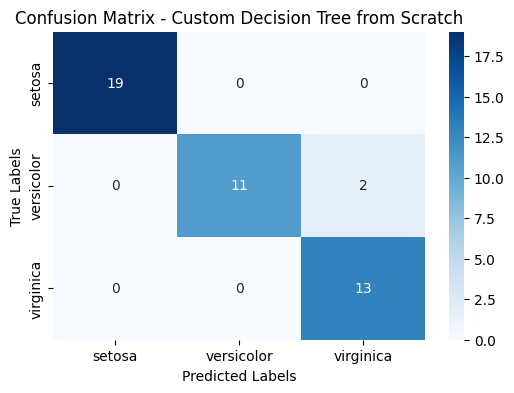

In [4]:
data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

custom_clf = DecisionTreeFromScratch(max_depth=4)
custom_clf.fit(X_train, y_train)
custom_preds = custom_clf.predict(X_test)
custom_acc = accuracy_score(y_test, custom_preds)

sklearn_clf = SklearnDecisionTree(max_depth=4, criterion='entropy', random_state=42)
sklearn_clf.fit(X_train, y_train)
sklearn_preds = sklearn_clf.predict(X_test)
sklearn_acc = accuracy_score(y_test, sklearn_preds)

print(f"Custom Scratch Model Accuracy : {custom_acc * 100:.2f}%")
print(f"Sklearn Model Accuracy        : {sklearn_acc * 100:.2f}%")

cm = confusion_matrix(y_test, custom_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title('Confusion Matrix - Custom Decision Tree from Scratch')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [6]:
def print_tree(node, indent="", is_left=None):
    if node is None:
        return

    if is_left is True:
        prefix = "├── [Left]  "
        next_indent = indent + "│   "
    elif is_left is False:
        prefix = "└── [Right] "
        next_indent = indent + "    "
    else:
        prefix = "[Root] "
        next_indent = indent + "    "

    if node.is_leaf_node():
        print(f"{indent}{prefix}➔ Class: {data.target_names[node.value]}")
        return

    print(f"{indent}{prefix}Split Feature [{node.feature}] <= {node.threshold:.2f}")

    print_tree(node.left, next_indent, is_left=True)
    print_tree(node.right, next_indent, is_left=False)

In [7]:
print_tree(custom_clf.root)

[Root] Split Feature [2] <= 1.90
    ├── [Left]  ➔ Class: setosa
    └── [Right] Split Feature [2] <= 4.70
        ├── [Left]  Split Feature [3] <= 1.50
        │   ├── [Left]  ➔ Class: versicolor
        │   └── [Right] ➔ Class: virginica
        └── [Right] Split Feature [2] <= 5.10
            ├── [Left]  Split Feature [3] <= 1.70
            │   ├── [Left]  ➔ Class: versicolor
            │   └── [Right] ➔ Class: virginica
            └── [Right] ➔ Class: virginica
